# HW10-11 – компьютерное зрение в PyTorch

## 1. Импорты, seed и устройство

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import json
import os
import csv
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('homeworks/HW10-11/artifacts/figures', exist_ok=True)

Using device: cuda


100%|██████████| 2.64G/2.64G [00:57<00:00, 46.2MB/s]


Batch shape: torch.Size([64, 3, 96, 96])
Labels shape: torch.Size([64])
Number of classes: 10
Train size: 4000
Val size: 1000
Test size: 8000


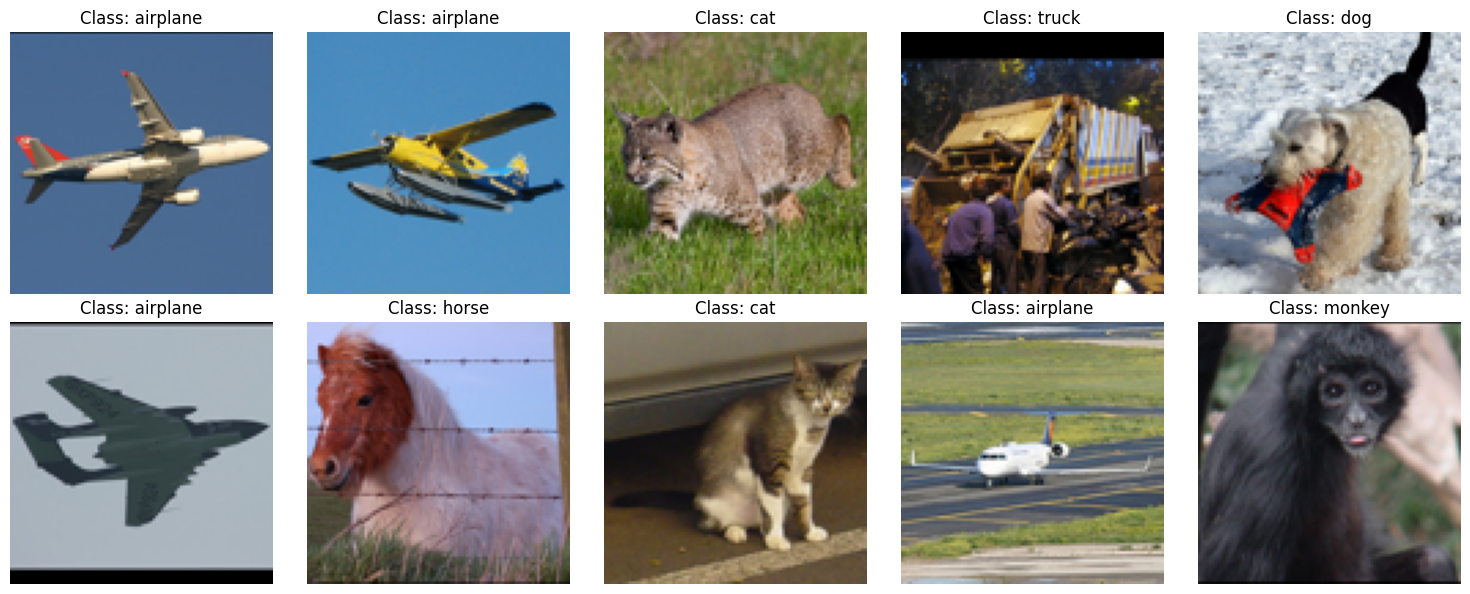

In [2]:
basic_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

augmentation_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=basic_transform)
test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=basic_transform)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(SEED))

train_dataset_base = train_dataset
train_dataset_aug = random_split(datasets.STL10(root='./data', split='train',
                                                download=True, transform=augmentation_transform),
                                 [train_size, val_size],
                                 generator=torch.Generator().manual_seed(SEED))[0]

train_dataset_resnet = random_split(datasets.STL10(root='./data', split='train',
                                                   download=True, transform=resnet_transform),
                                    [train_size, val_size],
                                    generator=torch.Generator().manual_seed(SEED))[0]
val_dataset_resnet = random_split(datasets.STL10(root='./data', split='train',
                                                 download=True, transform=resnet_transform),
                                  [train_size, val_size],
                                  generator=torch.Generator().manual_seed(SEED))[1]
test_dataset_resnet = datasets.STL10(root='./data', split='test', download=True,
                                     transform=resnet_transform)

batch_size = 64
train_loader_base = DataLoader(train_dataset_base, batch_size=batch_size, shuffle=True, num_workers=2)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2)
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_base = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_base = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False, num_workers=2)

sample_batch = next(iter(train_loader_base))
print(f"Batch shape: {sample_batch[0].shape}")
print(f"Labels shape: {sample_batch[1].shape}")
print(f"Number of classes: {len(train_dataset.dataset.classes)}")
print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset_base[i]
    img = img.permute(1, 2, 0).numpy()
    img = img * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(f'Class: {train_dataset.dataset.classes[label]}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('homeworks/HW10-11/artifacts/figures/classification_samples.png', dpi=100, bbox_inches='tight')
plt.show()

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(dataloader), 100. * correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(dataloader), 100. * correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        print(f'Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return history, best_val_acc, best_model_state

In [4]:
num_classes = 10
criterion = nn.CrossEntropyLoss()

model_c1 = SimpleCNN(num_classes).to(device)
optimizer_c1 = optim.Adam(model_c1.parameters(), lr=0.001)

history_c1, best_val_acc_c1, best_model_c1 = train_model(
    model_c1, train_loader_base, val_loader_base, criterion, optimizer_c1,
    epochs=20, device=device
)

test_loss_c1, test_acc_c1 = evaluate(model_c1, test_loader_base, criterion, device)
print(f"Test Accuracy C1: {test_acc_c1:.2f}%")

Epoch 1/20: Train Loss: 2.2164, Train Acc: 14.22%, Val Loss: 2.0719, Val Acc: 20.70%
Epoch 2/20: Train Loss: 2.0032, Train Acc: 22.45%, Val Loss: 1.8471, Val Acc: 27.20%
Epoch 3/20: Train Loss: 1.8184, Train Acc: 26.52%, Val Loss: 1.6914, Val Acc: 32.30%
Epoch 4/20: Train Loss: 1.7215, Train Acc: 29.48%, Val Loss: 1.6315, Val Acc: 33.10%
Epoch 5/20: Train Loss: 1.7024, Train Acc: 30.95%, Val Loss: 1.6907, Val Acc: 30.70%
Epoch 6/20: Train Loss: 1.6667, Train Acc: 32.33%, Val Loss: 1.6633, Val Acc: 31.80%
Epoch 7/20: Train Loss: 1.6647, Train Acc: 31.88%, Val Loss: 1.5815, Val Acc: 35.60%
Epoch 8/20: Train Loss: 1.6107, Train Acc: 34.58%, Val Loss: 1.5569, Val Acc: 37.30%
Epoch 9/20: Train Loss: 1.5894, Train Acc: 35.38%, Val Loss: 1.5136, Val Acc: 38.10%
Epoch 10/20: Train Loss: 1.5684, Train Acc: 35.73%, Val Loss: 1.5107, Val Acc: 37.60%
Epoch 11/20: Train Loss: 1.5517, Train Acc: 37.00%, Val Loss: 1.5266, Val Acc: 38.30%
Epoch 12/20: Train Loss: 1.5141, Train Acc: 38.48%, Val Loss: 1

In [5]:
model_c2 = SimpleCNN(num_classes).to(device)
optimizer_c2 = optim.Adam(model_c2.parameters(), lr=0.001)

history_c2, best_val_acc_c2, best_model_c2 = train_model(
    model_c2, train_loader_aug, val_loader_base, criterion, optimizer_c2,
    epochs=20, device=device
)

test_loss_c2, test_acc_c2 = evaluate(model_c2, test_loader_base, criterion, device)
print(f"Test Accuracy C2: {test_acc_c2:.2f}%")

Epoch 1/20: Train Loss: 2.2194, Train Acc: 14.38%, Val Loss: 2.0690, Val Acc: 18.60%
Epoch 2/20: Train Loss: 2.0217, Train Acc: 20.98%, Val Loss: 1.8305, Val Acc: 28.90%
Epoch 3/20: Train Loss: 1.8739, Train Acc: 25.02%, Val Loss: 1.7046, Val Acc: 30.40%
Epoch 4/20: Train Loss: 1.7927, Train Acc: 28.35%, Val Loss: 1.6540, Val Acc: 32.20%
Epoch 5/20: Train Loss: 1.7471, Train Acc: 29.80%, Val Loss: 1.6486, Val Acc: 31.20%
Epoch 6/20: Train Loss: 1.7109, Train Acc: 31.02%, Val Loss: 1.5939, Val Acc: 35.40%
Epoch 7/20: Train Loss: 1.7152, Train Acc: 30.20%, Val Loss: 1.6009, Val Acc: 35.40%
Epoch 8/20: Train Loss: 1.6638, Train Acc: 31.82%, Val Loss: 1.5560, Val Acc: 36.90%
Epoch 9/20: Train Loss: 1.6490, Train Acc: 32.92%, Val Loss: 1.5597, Val Acc: 35.70%
Epoch 10/20: Train Loss: 1.6478, Train Acc: 33.62%, Val Loss: 1.5499, Val Acc: 36.70%
Epoch 11/20: Train Loss: 1.6374, Train Acc: 33.10%, Val Loss: 1.5496, Val Acc: 37.40%
Epoch 12/20: Train Loss: 1.5961, Train Acc: 35.12%, Val Loss: 1

In [7]:
model_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model_c3.parameters():
    param.requires_grad = False

num_features = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_features, num_classes)
model_c3 = model_c3.to(device)

optimizer_c3 = optim.Adam(model_c3.fc.parameters(), lr=0.001)

history_c3, best_val_acc_c3, best_model_c3 = train_model(
    model_c3, train_loader_resnet, val_loader_resnet, criterion, optimizer_c3,
    epochs=20, device=device
)

test_loss_c3, test_acc_c3 = evaluate(model_c3, test_loader_resnet, criterion, device)
print(f"Test Accuracy C3: {test_acc_c3:.2f}%")

Epoch 1/20: Train Loss: 1.0677, Train Acc: 73.90%, Val Loss: 0.4467, Val Acc: 90.90%
Epoch 2/20: Train Loss: 0.3482, Train Acc: 93.22%, Val Loss: 0.2886, Val Acc: 92.90%
Epoch 3/20: Train Loss: 0.2548, Train Acc: 94.22%, Val Loss: 0.2420, Val Acc: 94.60%
Epoch 4/20: Train Loss: 0.2083, Train Acc: 94.60%, Val Loss: 0.2163, Val Acc: 94.00%
Epoch 5/20: Train Loss: 0.1827, Train Acc: 95.47%, Val Loss: 0.1988, Val Acc: 94.20%
Epoch 6/20: Train Loss: 0.1603, Train Acc: 95.67%, Val Loss: 0.1926, Val Acc: 94.60%
Epoch 7/20: Train Loss: 0.1497, Train Acc: 95.95%, Val Loss: 0.1877, Val Acc: 94.80%
Epoch 8/20: Train Loss: 0.1378, Train Acc: 96.12%, Val Loss: 0.1819, Val Acc: 94.30%
Epoch 9/20: Train Loss: 0.1298, Train Acc: 96.35%, Val Loss: 0.1769, Val Acc: 94.40%
Epoch 10/20: Train Loss: 0.1251, Train Acc: 96.50%, Val Loss: 0.1791, Val Acc: 94.20%
Epoch 11/20: Train Loss: 0.1157, Train Acc: 96.95%, Val Loss: 0.1769, Val Acc: 94.60%
Epoch 12/20: Train Loss: 0.1062, Train Acc: 97.08%, Val Loss: 0

In [8]:
model_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model_c4.parameters():
    param.requires_grad = False

for param in model_c4.layer4.parameters():
    param.requires_grad = True

num_features = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_features, num_classes)
model_c4 = model_c4.to(device)

optimizer_c4 = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=0.0001)

history_c4, best_val_acc_c4, best_model_c4 = train_model(
    model_c4, train_loader_resnet, val_loader_resnet, criterion, optimizer_c4,
    epochs=20, device=device
)

test_loss_c4, test_acc_c4 = evaluate(model_c4, test_loader_resnet, criterion, device)
print(f"Test Accuracy C4: {test_acc_c4:.2f}%")

Epoch 1/20: Train Loss: 0.6377, Train Acc: 82.92%, Val Loss: 0.2331, Val Acc: 92.80%
Epoch 2/20: Train Loss: 0.1153, Train Acc: 97.65%, Val Loss: 0.1854, Val Acc: 94.20%
Epoch 3/20: Train Loss: 0.0407, Train Acc: 99.83%, Val Loss: 0.1699, Val Acc: 94.90%
Epoch 4/20: Train Loss: 0.0175, Train Acc: 100.00%, Val Loss: 0.1682, Val Acc: 95.00%
Epoch 5/20: Train Loss: 0.0114, Train Acc: 100.00%, Val Loss: 0.1692, Val Acc: 95.10%
Epoch 6/20: Train Loss: 0.0083, Train Acc: 100.00%, Val Loss: 0.1620, Val Acc: 95.40%
Epoch 7/20: Train Loss: 0.0054, Train Acc: 100.00%, Val Loss: 0.1637, Val Acc: 95.60%
Epoch 8/20: Train Loss: 0.0046, Train Acc: 100.00%, Val Loss: 0.1662, Val Acc: 95.10%
Epoch 9/20: Train Loss: 0.0038, Train Acc: 100.00%, Val Loss: 0.1671, Val Acc: 95.40%
Epoch 10/20: Train Loss: 0.0031, Train Acc: 100.00%, Val Loss: 0.1672, Val Acc: 95.20%
Epoch 11/20: Train Loss: 0.0023, Train Acc: 100.00%, Val Loss: 0.1628, Val Acc: 95.00%
Epoch 12/20: Train Loss: 0.0021, Train Acc: 100.00%, Va

In [9]:
experiments = {
    'C1': {'val_acc': best_val_acc_c1, 'test_acc': test_acc_c1, 'model': best_model_c1, 'history': history_c1},
    'C2': {'val_acc': best_val_acc_c2, 'test_acc': test_acc_c2, 'model': best_model_c2, 'history': history_c2},
    'C3': {'val_acc': best_val_acc_c3, 'test_acc': test_acc_c3, 'model': best_model_c3, 'history': history_c3},
    'C4': {'val_acc': best_val_acc_c4, 'test_acc': test_acc_c4, 'model': best_model_c4, 'history': history_c4},
}

best_exp = max(experiments, key=lambda x: experiments[x]['val_acc'])
print(f"\nBest experiment: {best_exp}")
print(f"Best validation accuracy: {experiments[best_exp]['val_acc']:.2f}%")
print(f"Test accuracy: {experiments[best_exp]['test_acc']:.2f}%")

torch.save(experiments[best_exp]['model'], 'homeworks/HW10-11/artifacts/best_classifier.pt')

config = {
    'dataset': 'STL10',
    'architecture': 'SimpleCNN' if best_exp in ['C1', 'C2'] else 'ResNet18',
    'experiment': best_exp,
    'num_classes': 10,
    'seed': SEED,
    'best_val_accuracy': experiments[best_exp]['val_acc'],
    'test_accuracy': experiments[best_exp]['test_acc']
}
with open('homeworks/HW10-11/artifacts/best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=2)


Best experiment: C4
Best validation accuracy: 95.70%
Test accuracy: 95.30%


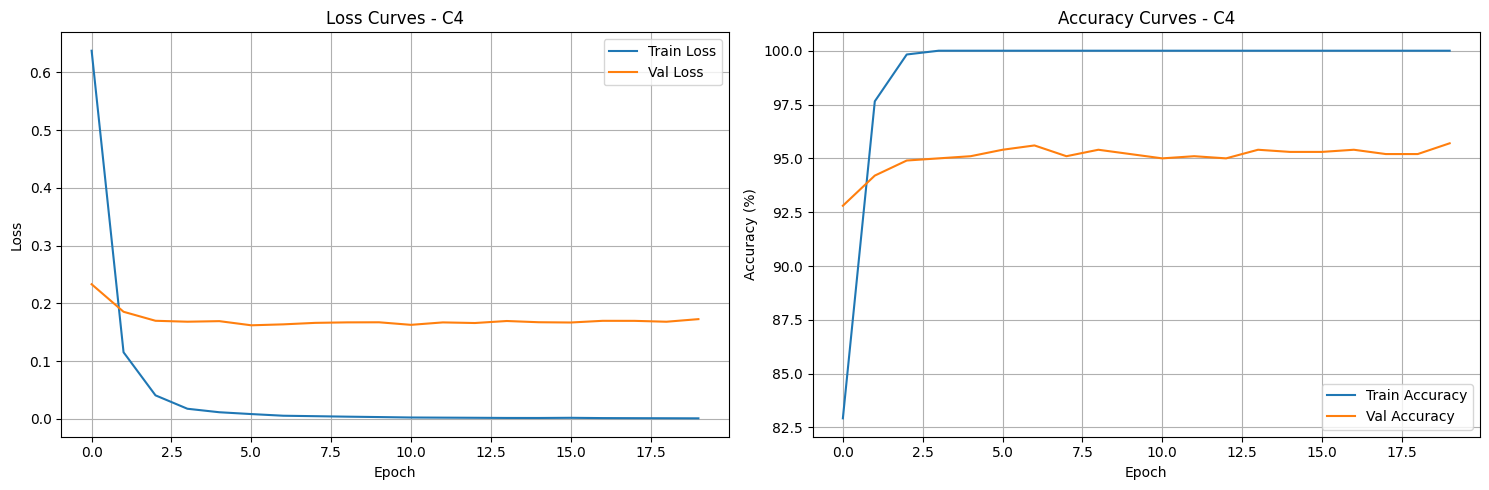

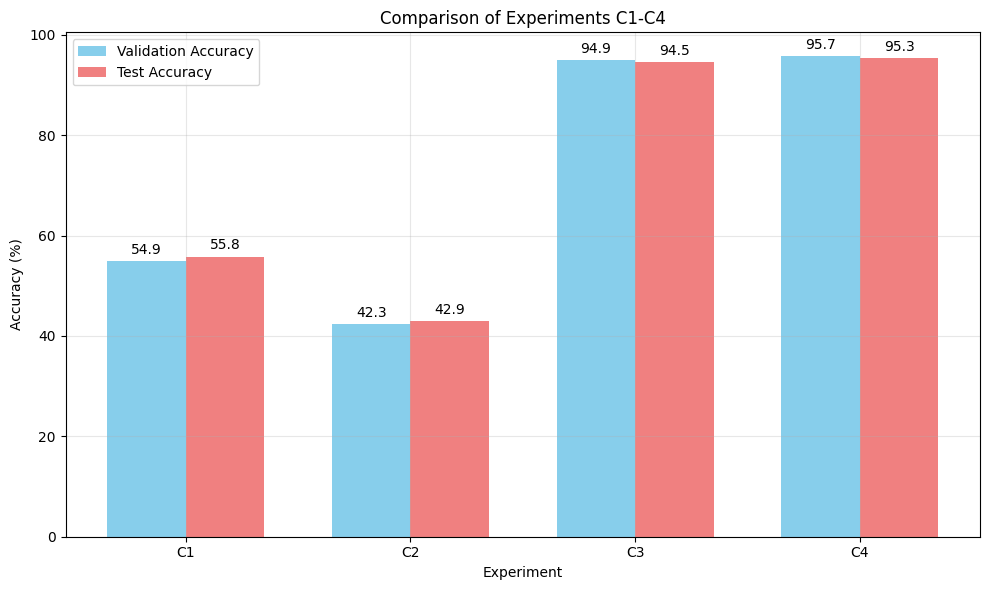

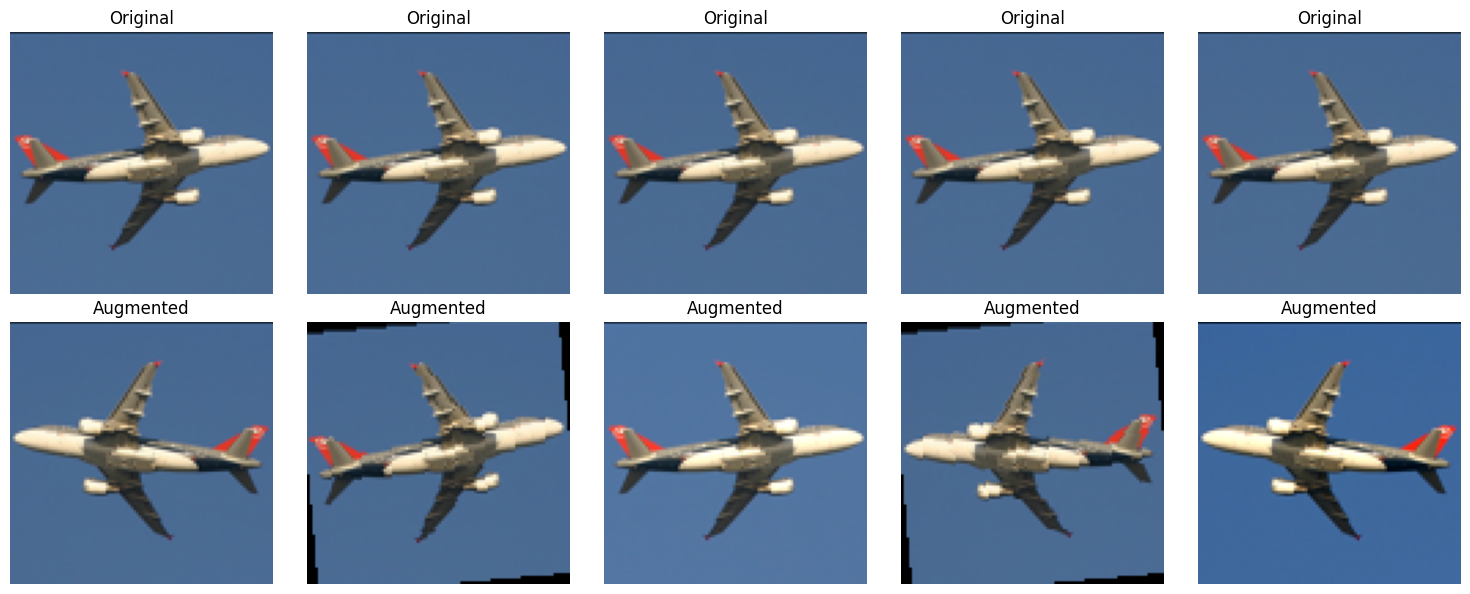

In [11]:
best_history = experiments[best_exp]['history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(best_history['train_loss'], label='Train Loss')
ax1.plot(best_history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title(f'Loss Curves - {best_exp}')
ax1.legend()
ax1.grid(True)

ax2.plot(best_history['train_acc'], label='Train Accuracy')
ax2.plot(best_history['val_acc'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title(f'Accuracy Curves - {best_exp}')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('homeworks/HW10-11/artifacts/figures/classification_curves_best.png', dpi=100, bbox_inches='tight')
plt.show()

exp_names = list(experiments.keys())
val_accs = [experiments[e]['val_acc'] for e in exp_names]
test_accs = [experiments[e]['test_acc'] for e in exp_names]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(exp_names))
width = 0.35

bars1 = ax.bar(x - width/2, val_accs, width, label='Validation Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='lightcoral')

ax.set_xlabel('Experiment')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparison of Experiments C1-C4')
ax.set_xticks(x)
ax.set_xticklabels(exp_names)
ax.legend()
ax.grid(True, alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center',
                       va='bottom')

plt.tight_layout()
plt.savefig('homeworks/HW10-11/artifacts/figures/classification_compare.png', dpi=100, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

sample_img_tensor, sample_label = train_dataset_base[0]
sample_img_np = sample_img_tensor.permute(1, 2, 0).numpy()
sample_img_np = sample_img_np * 0.5 + 0.5
sample_img_np = np.clip(sample_img_np, 0, 1)

sample_img_pil = Image.fromarray((sample_img_np * 255).astype('uint8'))

for i in range(5):
    axes[0, i].imshow(sample_img_np)
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')


    if i == 0:
        aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    elif i == 1:
        aug_transform = transforms.Compose([
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    elif i == 2:
        aug_transform = transforms.Compose([
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    elif i == 3:
        aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
    else:
        aug_transform = transforms.Compose([
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    aug_img_tensor = aug_transform(sample_img_pil)
    aug_img_np = aug_img_tensor.permute(1, 2, 0).numpy()
    aug_img_np = aug_img_np * 0.5 + 0.5
    aug_img_np = np.clip(aug_img_np, 0, 1)

    axes[1, i].imshow(aug_img_np)
    axes[1, i].set_title('Augmented')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('homeworks/HW10-11/artifacts/figures/augmentations_preview.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
from torchvision.datasets import VOCDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision import transforms as T
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class DetectionTransform:
    def __call__(self, image, target):
        image = T.ToTensor()(image)
        return image, target

detection_dataset = VOCDetection(
    root='./data',
    year='2012',
    image_set='val',
    download=True,
    transform=None
)

subset_size = 50
detection_dataset = torch.utils.data.Subset(detection_dataset, range(min(subset_size, len(detection_dataset))))

detection_model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
detection_model.eval()
detection_model.to(device)

print(f"Detection dataset size: {len(detection_dataset)}")

VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor'
]
print(f"Number of classes (including background): {len(VOC_CLASSES)}")

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

def evaluate_detection(model, dataset, device, score_threshold=0.5):
    model.eval()
    all_precisions = []
    all_recalls = []
    all_ious = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            img, target = dataset[idx]
            img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)

            predictions = model(img_tensor)[0]

            keep = predictions['scores'] >= score_threshold
            pred_boxes = predictions['boxes'][keep].cpu().numpy()
            pred_scores = predictions['scores'][keep].cpu().numpy()

            gt_boxes = []

            annotation = target['annotation']

            if 'object' in annotation:
                objects = annotation['object']
                if not isinstance(objects, list):
                    objects = [objects]

                for obj in objects:
                    if 'bndbox' in obj:
                        bbox = obj['bndbox']
                        try:
                            gt_boxes.append([
                                float(bbox['xmin']), float(bbox['ymin']),
                                float(bbox['xmax']), float(bbox['ymax'])
                            ])
                        except (ValueError, TypeError):
                            continue

            gt_boxes = np.array(gt_boxes)

            if len(gt_boxes) == 0:
                continue

            matched_gt = set()
            matched_pred = set()
            ious_list = []

            for i, pred_box in enumerate(pred_boxes):
                best_iou = 0
                best_gt_idx = -1
                for j, gt_box in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue
                    iou = compute_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j

                if best_iou >= 0.5:
                    matched_gt.add(best_gt_idx)
                    matched_pred.add(i)
                    ious_list.append(best_iou)

            tp = len(matched_pred)
            fp = len(pred_boxes) - tp
            fn = len(gt_boxes) - len(matched_gt)

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            mean_iou = np.mean(ious_list) if ious_list else 0

            all_precisions.append(precision)
            all_recalls.append(recall)
            all_ious.append(mean_iou)

    return {
        'precision': np.mean(all_precisions),
        'recall': np.mean(all_recalls),
        'mean_iou': np.mean(all_ious)
    }

print("Detection setup complete!")

Detection dataset size: 50
Number of classes (including background): 21
Detection setup complete!


In [15]:
print("V1: Evaluating with score_threshold=0.3")
metrics_v1 = evaluate_detection(detection_model, detection_dataset, device, score_threshold=0.3)
print(f"Precision: {metrics_v1['precision']:.4f}")
print(f"Recall: {metrics_v1['recall']:.4f}")
print(f"Mean IoU: {metrics_v1['mean_iou']:.4f}")

print("\nV2: Evaluating with score_threshold=0.7")
metrics_v2 = evaluate_detection(detection_model, detection_dataset, device, score_threshold=0.7)
print(f"Precision: {metrics_v2['precision']:.4f}")
print(f"Recall: {metrics_v2['recall']:.4f}")
print(f"Mean IoU: {metrics_v2['mean_iou']:.4f}")

V1: Evaluating with score_threshold=0.3
Precision: 0.3929
Recall: 0.9675
Mean IoU: 0.8217

V2: Evaluating with score_threshold=0.7
Precision: 0.6706
Recall: 0.8273
Mean IoU: 0.7903



Visualizing detection results with threshold=0.3


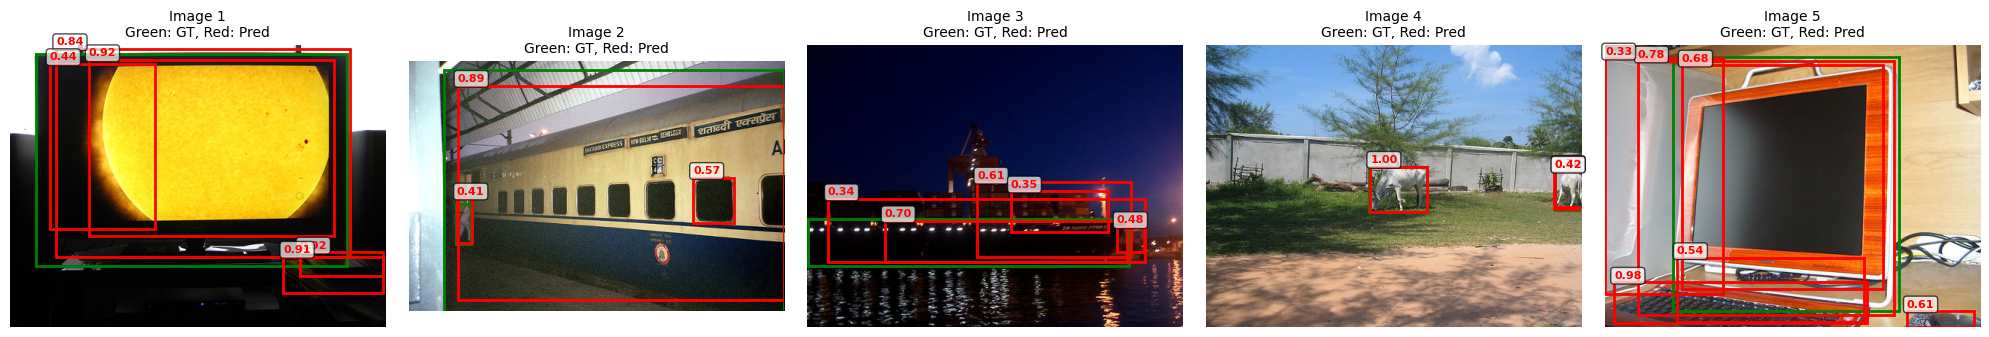


Visualizing detection results with threshold=0.7


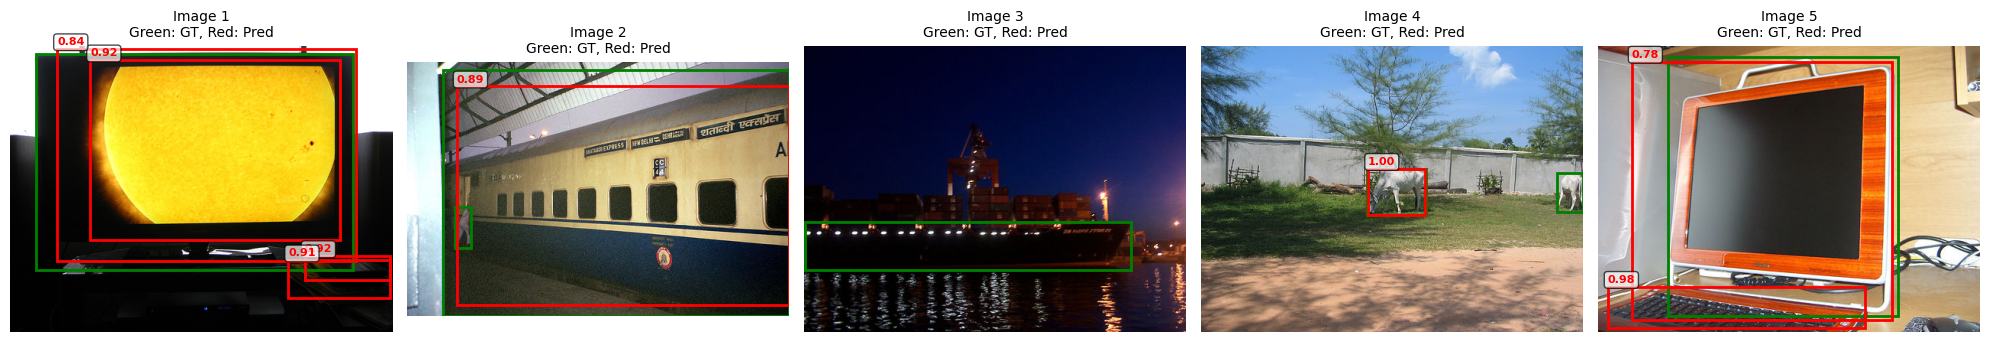

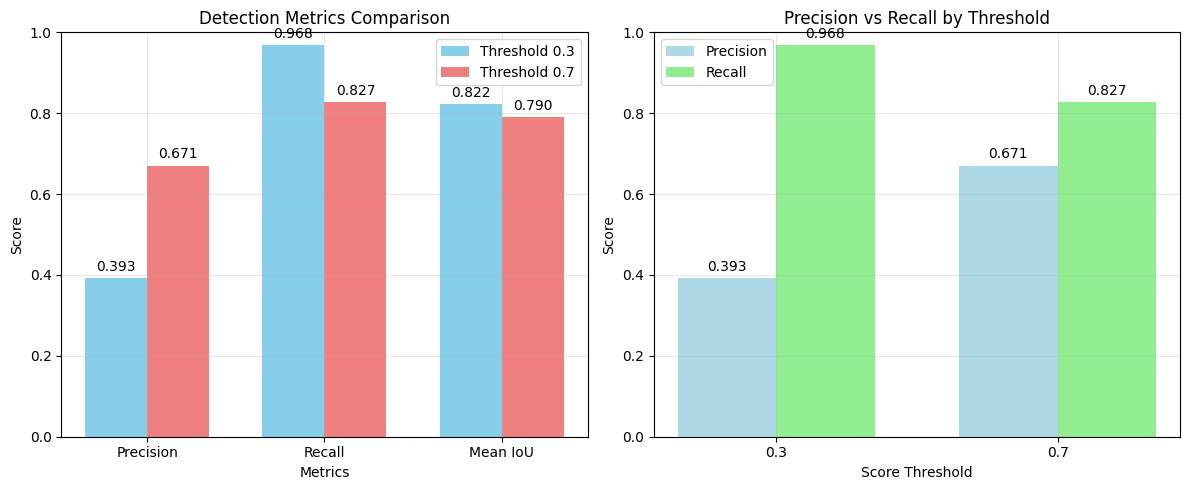


Detection evaluation complete!


In [16]:
def visualize_detections(model, dataset, device, score_threshold=0.5, num_examples=5):
    model.eval()
    num_examples = min(num_examples, len(dataset))
    fig, axes = plt.subplots(1, num_examples, figsize=(20, 4))

    if num_examples == 1:
        axes = [axes]

    with torch.no_grad():
        for idx in range(num_examples):
            img, target = dataset[idx]


            img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)
            predictions = model(img_tensor)[0]

            keep = predictions['scores'] >= score_threshold
            pred_boxes = predictions['boxes'][keep].cpu().numpy()
            pred_scores = predictions['scores'][keep].cpu().numpy()

            gt_boxes = []
            annotation = target['annotation']

            if 'object' in annotation:
                objects = annotation['object']
                if not isinstance(objects, list):
                    objects = [objects]

                for obj in objects:
                    if 'bndbox' in obj:
                        bbox = obj['bndbox']
                        try:
                            gt_boxes.append([
                                float(bbox['xmin']), float(bbox['ymin']),
                                float(bbox['xmax']), float(bbox['ymax'])
                            ])
                        except (ValueError, TypeError):
                            continue


            axes[idx].imshow(img)
            axes[idx].axis('off')

            for box in gt_boxes:
                rect = patches.Rectangle(
                    (box[0], box[1]),
                    box[2] - box[0],
                    box[3] - box[1],
                    linewidth=2,
                    edgecolor='green',
                    facecolor='none'
                )
                axes[idx].add_patch(rect)

            for box, score in zip(pred_boxes, pred_scores):
                rect = patches.Rectangle(
                    (box[0], box[1]),
                    box[2] - box[0],
                    box[3] - box[1],
                    linewidth=2,
                    edgecolor='red',
                    facecolor='none'
                )
                axes[idx].add_patch(rect)
                axes[idx].text(
                    box[0],
                    box[1] - 5,
                    f'{score:.2f}',
                    color='red',
                    fontsize=8,
                    weight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
                )

            axes[idx].set_title(f'Image {idx+1}\nGreen: GT, Red: Pred', fontsize=10)

    plt.tight_layout()
    return fig

print("\nVisualizing detection results with threshold=0.3")
try:
    fig_v1 = visualize_detections(detection_model, detection_dataset, device, score_threshold=0.3, num_examples=5)
    plt.savefig('homeworks/HW10-11/artifacts/figures/detection_examples_v1.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as e:
    print(f"Error in V1 visualization: {e}")

print("\nVisualizing detection results with threshold=0.7")
try:
    fig_v2 = visualize_detections(detection_model, detection_dataset, device, score_threshold=0.7, num_examples=5)
    plt.savefig('homeworks/HW10-11/artifacts/figures/detection_examples_v2.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()
except Exception as e:
    print(f"Error in V2 visualization: {e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics_names = ['Precision', 'Recall', 'Mean IoU']
v1_values = [metrics_v1['precision'], metrics_v1['recall'], metrics_v1['mean_iou']]
v2_values = [metrics_v2['precision'], metrics_v2['recall'], metrics_v2['mean_iou']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, v1_values, width, label='Threshold 0.3', color='skyblue')
bars2 = axes[0].bar(x + width/2, v2_values, width, label='Threshold 0.7', color='lightcoral')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Detection Metrics Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0].annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3),
                           textcoords="offset points",
                           ha='center',
                           va='bottom')

thresholds = [0.3, 0.7]
precisions = [metrics_v1['precision'], metrics_v2['precision']]
recalls = [metrics_v1['recall'], metrics_v2['recall']]

x = np.arange(len(thresholds))
width = 0.35

bars1 = axes[1].bar(x - width/2, precisions, width, label='Precision', color='lightblue')
bars2 = axes[1].bar(x + width/2, recalls, width, label='Recall', color='lightgreen')
axes[1].set_xlabel('Score Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall by Threshold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'0.3', f'0.7'])
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[1].annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width()/2, height),
                           xytext=(0, 3),
                           textcoords="offset points",
                           ha='center',
                           va='bottom')

plt.tight_layout()
plt.savefig('homeworks/HW10-11/artifacts/figures/detection_metrics.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()

print("\nDetection evaluation complete!")